### Data Set Preparation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Use data collected from a back yard at a +/- 8 Gauss resolution on 4/1/24
# The actual data set is not provided as it contains exact latitude and longitute coordinates of a person's home
G8_4124 = pd.read_csv("magMapCapture8G_4_1_24.txt", sep=',')

In [4]:
# convert text file data into modifyable types compatible with pandas data structures
# convert string data to numeric data
col = ['X','Y','Z','Azimuth','Bearing','Latitude','Longitude','Altitude']
G8_4124[col] = G8_4124[col].apply(pd.to_numeric)
# convert date string to date object
col = ['Date']
G8_4124[col] = G8_4124[col].apply(lambda x: pd.to_datetime(x, format='%m/%d/%Y'))
# convert date string to date object
col = ['Time']
G8_4124[col] = G8_4124[col].apply(lambda x: pd.to_datetime(x, format='%H:%M:%S').dt.time)

In [5]:
# Functions used to convert raw digital data to nano Tesla
def convert_raw_to_mG(x, mode):
    if mode == 1: # assumes 2G/12000LSB ~ 0.167mG/LSB
        return 2/12000 * x
    else: # assumes 8G/3000LSB ~ 2.67mG/LSB 
        return 8/3000 * x
def convert_mG_to_nT(x):
    return 100 * x
def convert_raw_to_nT(x, mode):
    mg = convert_raw_to_mG(x, mode)
    return convert_mG_to_nT(mg)

In [6]:
# convert raw data to nT
col = ['X','Y','Z']
G8_4124[col] = G8_4124[col].apply(lambda x: round(convert_raw_to_nT(x, 0),1))

In [7]:
# Orientation: X = East, Y = North, Z = Straight Up
filter = (G8_4124['Direction'] == 'E') | (G8_4124['Direction'] == 'ESE') | (G8_4124['Direction'] == 'ENE')

# Latitude and Longitude (targets)
y = G8_4124.loc[filter, ['Longitude','Latitude']].values 

# X, Y, Z magnetic readings (features)
X = G8_4124.loc[filter, ['X','Y','Z']].values

### Data Split Creation

In [8]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Scaled
XSS = StandardScaler()
XSS.fit(X)
X_scaled = XSS.transform(X)

ySS = StandardScaler()
ySS.fit(y)
y_scaled = ySS.transform(y)

# Normalized
XMMS = MinMaxScaler()
X_norm = XMMS.fit_transform(X)

yMMS = MinMaxScaler()
y_norm = yMMS.fit_transform(y)

In [9]:
# Standard Split
# Split data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)

# Scaled Split
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=1)

# Normalized Split
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_norm, y_norm, test_size=0.3, random_state=1)

### Defining Metrics

In [10]:
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

def metrics(test, pred):
    mse = mean_squared_error(test, pred)
    print(f'Mean Squared Error: {mse:.3f}')
    
    mae = mean_absolute_error(test, pred)
    print(f'Mean Absolute Error: {mae:.3f}')
    
    r2 = r2_score(test, pred)
    print(f'R2 Score: {r2:.3f}')
    
    evs = explained_variance_score(test, pred)
    print(f'Explained Variance Score: {evs:.3f}')

### Decision Tree Regression

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Define parameter grid
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': range(3, 11),
    'min_samples_leaf': range(3, 11)
}

# Create DecisionTreeRegressor instance
tree = DecisionTreeRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=10, n_jobs=-1, verbose=1)

# Perform grid search
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Fitting 10 folds for each of 192 candidates, totalling 1920 fits
Best Parameters: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 4}
Best Score: 0.5767940795317341


In [33]:
best_tree = DecisionTreeRegressor(criterion=best_params.get('criterion'),
                                         max_depth=best_params.get('max_depth'),
                                         min_samples_leaf=best_params.get('min_samples_leaf'),
                                         random_state=42)
best_tree.fit(X_train_norm, y_train_norm)
y_pred = best_tree.predict(X_test_norm)
metrics(y_test_norm, y_pred)

Mean Squared Error: 0.032
Mean Absolute Error: 0.120
R2 Score: 0.567
Explained Variance Score: 0.568


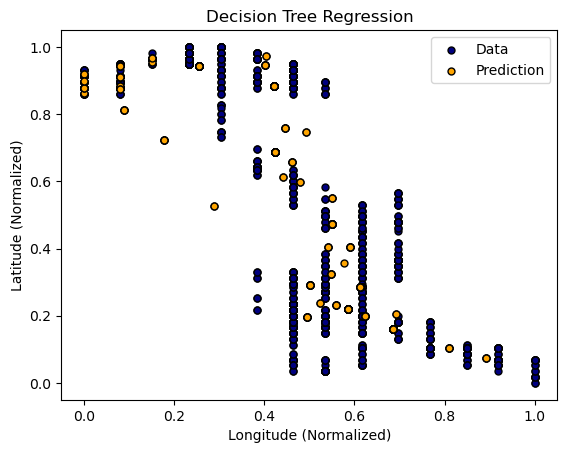

In [36]:
plt.figure()
s = 25
plt.scatter(y_norm[:, 0], y_norm[:, 1], c="navy", s=s, edgecolor="black", label="Data")
plt.scatter(y_pred[:, 0], y_pred[:, 1], color="orange", s=s, edgecolor="black", label="Prediction")
plt.xlabel("Longitude (Normalized)")
plt.ylabel("Latitude (Normalized)")
plt.title("Decision Tree Regression")
plt.legend(loc="best")
plt.show()

### Random Forest Regression

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150, 200],  # Number of trees in the forest
    'max_depth': range(1, 16),
    'min_samples_leaf': range(1, 6),
}

# Create RandomForestRegressor instance
rf_model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=10, n_jobs=-1, verbose=1)

# Perform grid search
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Fitting 10 folds for each of 300 candidates, totalling 3000 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}
Best Score: 0.6818630290321992


In [20]:
settings = {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 150}
mlp = RandomForestRegressor(**settings)
mlp.fit(X_train_norm, y_train_norm)
y_pred = mlp.predict(X_test_norm)
metrics(y_test_norm, y_pred)

Mean Squared Error: 0.025
Mean Absolute Error: 0.105
R2 Score: 0.656
Explained Variance Score: 0.658


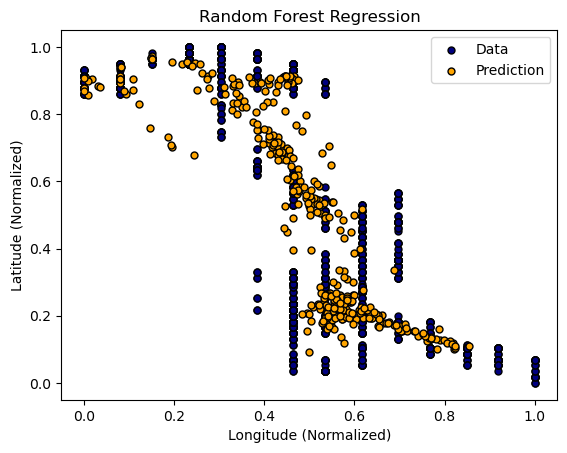

In [21]:
plt.figure()
s = 25
plt.scatter(y_norm[:, 0], y_norm[:, 1], c="navy", s=s, edgecolor="black", label="Data")
plt.scatter(y_pred[:, 0], y_pred[:, 1], color="orange", s=s, edgecolor="black", label="Prediction")
plt.xlabel("Longitude (Normalized)")
plt.ylabel("Latitude (Normalized)")
plt.title("Random Forest Regression")
plt.legend(loc="best")
plt.show()

### Multi-Output Support Vector Regression

In [11]:
# MSVR needs data to be in the range -1 to 1 (normalized) in order to function properly
import sys
sys.path.append('./msvr-master/msvr-master')
from model.MSVR import MSVR
from model.utility import rmse
#msvr = MSVR(kernel = 'rbf', gamma = 10, epsilon = 0.01, tol=0.01, C=100)
msvr = MSVR(kernel = 'rbf', gamma = 20, epsilon = 0.01, tol=0.01, C=100)
msvr.fit(X_train_norm, y_train_norm)
y_pred = msvr.predict(X_test_norm)
metrics(y_test_norm, y_pred)

Mean Squared Error: 0.027
Mean Absolute Error: 0.117
R2 Score: 0.638
Explained Variance Score: 0.638


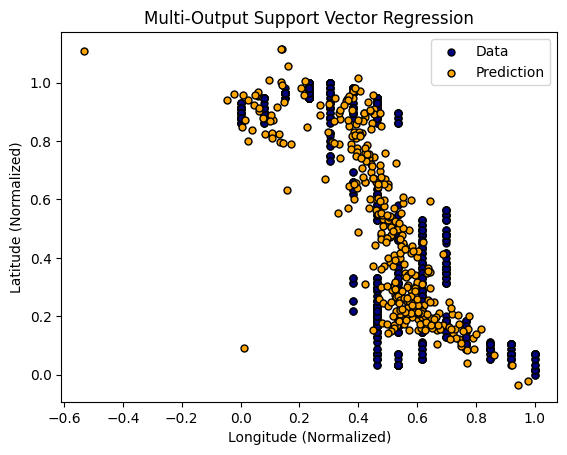

In [12]:
plt.figure()
s = 25
plt.scatter(y_norm[:, 0], y_norm[:, 1], c="navy", s=s, edgecolor="black", label="Data")
plt.scatter(y_pred[:, 0], y_pred[:, 1], color="orange", s=s, edgecolor="black", label="Prediction")
plt.xlabel("Longitude (Normalized)")
plt.ylabel("Latitude (Normalized)")
plt.title("Multi-Output Support Vector Regression")
plt.legend(loc="best")
plt.show()

### Optimal Parameter Search for Multi-Layer Perceptron

In [39]:
big = []
for i in range(21,41):
    for j in range(21, 41):
        for k in range(21, 41):
            big.append([i,j,k])

In [40]:
# Nerual Network
# Finding hyperparameters
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

param_grid = {
    'hidden_layer_sizes': big,
    'activation': ['relu'],  
    'solver': ['adam'],
    'alpha': [0.001],
    'random_state': [42],
    'max_iter': [50000],
    'learning_rate_init': [0.01],
    'batch_size': [100],
    'tol': [1e-6]
}

kf = KFold(n_splits=5, shuffle=False)
regr = MLPRegressor()
neuralNetwork = GridSearchCV(estimator=regr, param_grid=param_grid, cv=kf, n_jobs=-1, verbose=1, scoring='r2')

neuralNetwork.fit(X_train_norm, y_train_norm)

Fitting 5 folds for each of 8000 candidates, totalling 40000 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=MLPRegressor(), n_jobs=-1,
             param_grid={'activation': ['relu'], 'alpha': [0.001],
                         'batch_size': [100],
                         'hidden_layer_sizes': [[21, 21, 21], [21, 21, 22],
                                                [21, 21, 23], [21, 21, 24],
                                                [21, 21, 25], [21, 21, 26],
                                                [21, 21, 27], [21, 21, 28],
                                                [21, 21, 29], [21, 21, 30],
                                                [21, 21, 31], [21, 21, 32],
                                                [21, 21, 33], [21, 21, 34],
                                                [21, 21, 35], [21, 21, 36],
                                                [21, 21, 37], [21, 21, 38],
                                                [21, 21, 39], [21, 21, 40],
                                                [21, 22, 21], [21, 22, 22],
                                                [21, 22, 23], [21, 22, 24],
                                                [21, 22, 25], [21, 22, 26],
                                                [21, 22, 27], [21, 22, 28],
                                                [21, 22, 29], [21, 22, 30], ...],
                         'learning_rate_init': [0.01], 'max_iter': [50000],
                         'random_state': [42], 'solver': ['adam'],
                         'tol': [1e-06]},
             scoring='r2', verbose=1)

In [41]:
best_params = neuralNetwork.best_params_
best_score = neuralNetwork.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'activation': 'relu', 'alpha': 0.001, 'batch_size': 100, 'hidden_layer_sizes': [29, 35, 38], 'learning_rate_init': 0.01, 'max_iter': 50000, 'random_state': 42, 'solver': 'adam', 'tol': 1e-06}
Best Score: 0.6618413373815811


### Best Parameter Combinations

### Multi-Layer Perceptron Regression

In [28]:
from sklearn.neural_network import MLPRegressor

settings = {
    'activation': 'relu', 
    'alpha': 0.001, 
    'batch_size': 100, 
    'hidden_layer_sizes': [29, 35, 38], 
    'learning_rate_init': 0.01, 
    'max_iter': 50000, 
    'random_state': 42, 
    'solver': 'adam', 
    'tol': 1e-6
}
mlp = MLPRegressor(**settings)
mlp.fit(X_train_norm, y_train_norm)
y_pred = mlp.predict(X_test_norm)
metrics(y_test_norm, y_pred)

Mean Squared Error: 0.029
Mean Absolute Error: 0.123
R2 Score: 0.613
Explained Variance Score: 0.617


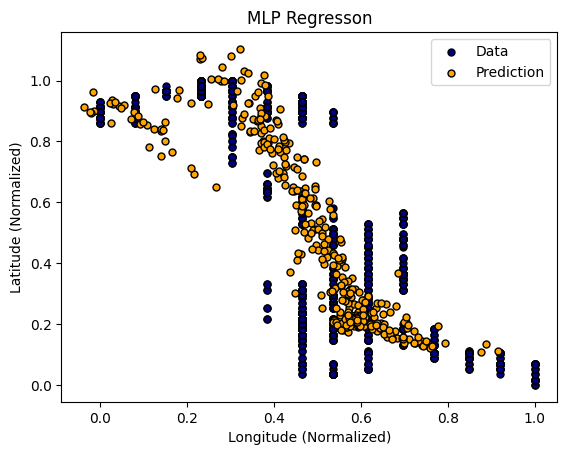

In [29]:
plt.figure()
s = 25
plt.scatter(y_norm[:, 0], y_norm[:, 1], c="navy", s=s, edgecolor="black", label="Data")
plt.scatter(y_pred[:, 0], y_pred[:, 1], color="orange", s=s, edgecolor="black", label="Prediction")
plt.xlabel("Longitude (Normalized)")
plt.ylabel("Latitude (Normalized)")
plt.title("MLP Regresson")
plt.legend(loc="best")
plt.show()

### Neural Network using PyTorch

In [24]:
import torch
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.nn as nn

In [25]:
# Define the model
model = nn.Sequential(
    nn.Linear(3, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 2)
)

In [20]:
import torch.optim as optim
 
# loss function and optimizer
loss_fn = nn.L1Loss()  # MAE
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [21]:
import tqdm
import copy
X_train_torch = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_norm, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_torch = torch.tensor(y_test_norm, dtype=torch.float32)

# training parameters
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train_torch), batch_size)

# Hold the best model
best_loss = np.inf   # init to infinity
best_weights = None
history = []

# training loop
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train_torch[start:start+batch_size]
            y_batch = y_train_torch[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(loss=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test_torch)
    loss = loss_fn(y_pred, y_test_torch)
    loss = float(loss)
    history.append(loss)
    if loss < best_loss:
        best_loss = loss
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)

<All keys matched successfully>

Loss: 0.37


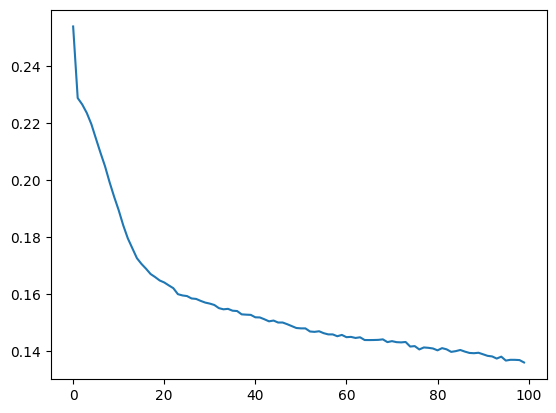

In [22]:
print("Loss: %.2f" % np.sqrt(best_loss))
plt.plot(history)
plt.show()

Mean Squared Error: 0.033
Mean Absolute Error: 0.136
R2 Score: 0.565
Explained Variance Score: 0.581


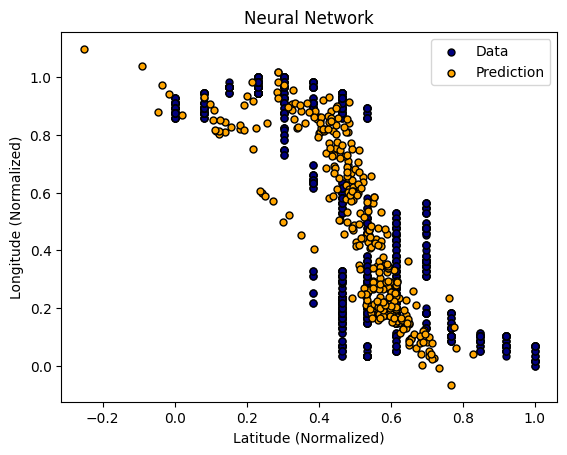

In [24]:
y_pred = model(X_test_torch).detach().numpy()
metrics(y_test_norm, y_pred)
plt.figure()
s = 25
plt.scatter(y_norm[:, 0], y_norm[:, 1], c="navy", s=s, edgecolor="black", label="Data")
plt.scatter(y_pred[:, 0], y_pred[:, 1], color="orange", s=s, edgecolor="black", label="Prediction")
#plt.xlim(25.6252, 25.62532)
#plt.ylim(-80.42014,-80.42004)
#plt.xlim(25.6, 25.65)
#plt.ylim(-80.5,-80.4)
plt.xlabel("Latitude (Normalized)")
plt.ylabel("Longitude (Normalized)")
plt.title("Neural Network")
plt.legend(loc="best")
plt.show()

### Deep Learning using Keras

In [12]:
# Deep learning
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from matplotlib import pyplot

# define model
model = Sequential()
model.add(Dense(25, input_dim=3, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(2, activation='linear'))
opt = SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mse'])
# fit model
history = model.fit(X_train_norm, y_train_norm, validation_data=(X_test_norm, y_test_norm), epochs=100)
# evaluate the model
_, train_mse = model.evaluate(X_train_norm, y_train_norm, verbose=0)
_, test_mse = model.evaluate(X_test_norm, y_test_norm, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_mse, test_mse))

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4086 - mse: 0.4086 - val_loss: 0.1203 - val_mse: 0.1203
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1009 - mse: 0.1009 - val_loss: 0.0857 - val_mse: 0.0857
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0890 - mse: 0.0890 - val_loss: 0.0764 - val_mse: 0.0764
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0784 - mse: 0.0784 - val_loss: 0.0717 - val_mse: 0.0717
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0757 - mse: 0.0757 - val_loss: 0.0718 - val_mse: 0.0718
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0719 - mse: 0.0719 - val_loss: 0.0672 - val_mse: 0.0672
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0723 - mse: 0.0723 - val_loss: 0.0722 - val_mse: 0.0722
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0813 - mse: 0.0813 - val_loss: 0.0652 - val_mse: 0.0652
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.07

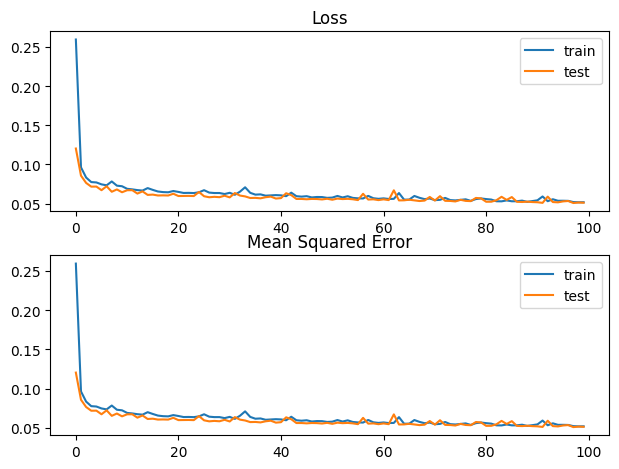

In [16]:
# plot loss during training
pyplot.subplot(211)
pyplot.title('Loss')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
# plot mse during training
pyplot.subplot(212)
pyplot.tight_layout()
pyplot.title('Mean Squared Error')
pyplot.plot(history.history['mse'], label='train')
pyplot.plot(history.history['val_mse'], label='test')
pyplot.legend()
pyplot.show()

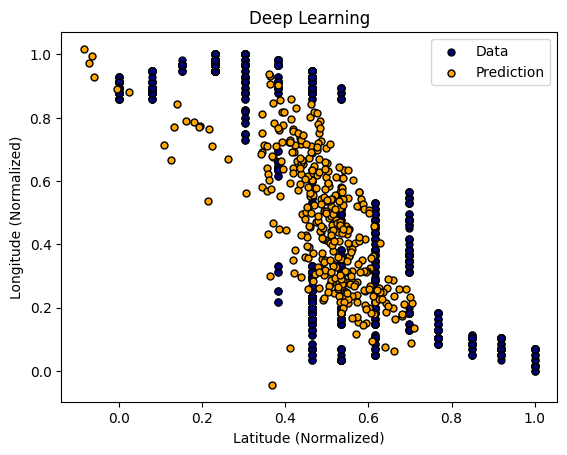

In [22]:
y_pred = model(X_test_norm)
plt.figure()
s = 25
plt.scatter(y_norm[:, 0], y_norm[:, 1], c="navy", s=s, edgecolor="black", label="Data")
plt.scatter(y_pred[:, 0], y_pred[:, 1], color="orange", s=s, edgecolor="black", label="Prediction")
plt.xlabel("Latitude (Normalized)")
plt.ylabel("Longitude (Normalized)")
plt.title("Deep Learning")
plt.legend(loc="best")
plt.show()